In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Heart Disease Text Classification - Baseline Models

## 1. Import Libraries

In [2]:
# Core libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Text preprocessing
import re
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

# Feature extraction
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer

# Model training
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import LabelEncoder

# Evaluation
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, roc_auc_score, roc_curve
)

# Download NLTK data
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('punkt_tab')

# Settings
import warnings
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')

print("All libraries imported successfully!")

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...


All libraries imported successfully!


[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


## 2. Load Data

In [3]:
# Load the dataset
df = pd.read_csv(r'/content/drive/MyDrive/Multi_data/main_dataset.csv')

print(f"Dataset Shape: {df.shape}")
print(f"\nColumns: {df.columns.tolist()}")
df.head()

Dataset Shape: (1190, 2)

Columns: ['patient_data', 'label']


,patient_data,label
0,The patient is a 40-year-old male who presente...,No heart Disease
1,The patient is a 49-year-old female who presen...,Heart Disease
2,The patient is a 37-year-old male who presente...,No heart Disease
3,The patient is a 48-year-old female who presen...,Heart Disease
4,The patient is a 54-year-old male who presente...,No heart Disease


## 3. Exploratory Data Analysis (EDA)

In [4]:
# Basic info
print("=" * 50)
print("DATASET INFO")
print("=" * 50)
print(df.info())

print("\n" + "=" * 50)
print("MISSING VALUES")
print("=" * 50)
print(df.isnull().sum())

print("\n" + "=" * 50)
print("DUPLICATE ROWS")
print("=" * 50)
print(f"Number of duplicates: {df.duplicated().sum()}")

DATASET INFO
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1190 entries, 0 to 1189
Data columns (total 2 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   patient_data  1190 non-null   object
 1   label         1190 non-null   object
dtypes: object(2)
memory usage: 18.7+ KB
None

MISSING VALUES
patient_data    0
label           0
dtype: int64

DUPLICATE ROWS
Number of duplicates: 0


LABEL DISTRIBUTION
label
Heart Disease       629
No heart Disease    561
Name: count, dtype: int64

Percentage:
label
Heart Disease       52.857143
No heart Disease    47.142857
Name: proportion, dtype: float64


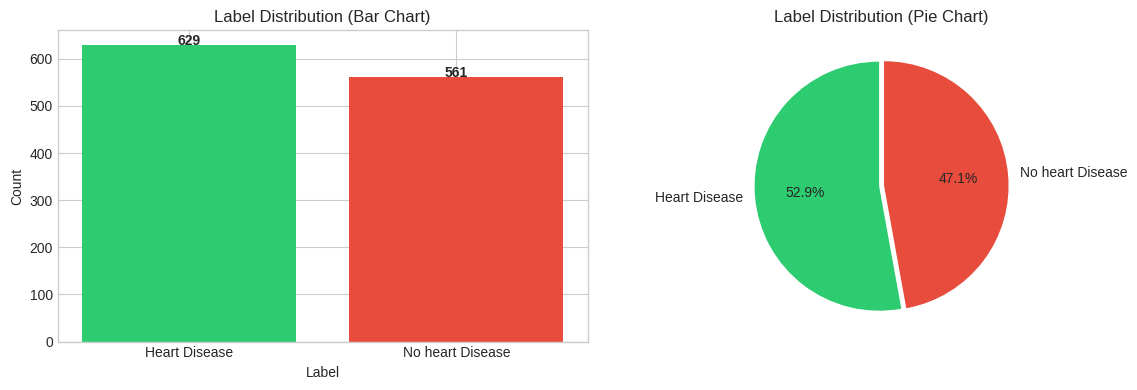

In [5]:
# Label distribution
print("=" * 50)
print("LABEL DISTRIBUTION")
print("=" * 50)
label_counts = df['label'].value_counts()
print(label_counts)
print(f"\nPercentage:")
print(df['label'].value_counts(normalize=True) * 100)

# Plot label distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar plot
colors = ['#2ecc71', '#e74c3c']
axes[0].bar(label_counts.index, label_counts.values, color=colors)
axes[0].set_xlabel('Label')
axes[0].set_ylabel('Count')
axes[0].set_title('Label Distribution (Bar Chart)')
for i, v in enumerate(label_counts.values):
    axes[0].text(i, v + 0.5, str(v), ha='center', fontweight='bold')

# Pie chart
axes[1].pie(label_counts.values, labels=label_counts.index, autopct='%1.1f%%',
            colors=colors, explode=[0.02, 0.02], startangle=90)
axes[1].set_title('Label Distribution (Pie Chart)')

plt.tight_layout()
plt.show()

TEXT LENGTH STATISTICS
       text_length   word_count
count  1190.000000  1190.000000
mean   1177.993277   168.021008
std     235.915581    31.261028
min     399.000000    65.000000
25%    1139.250000   163.000000
50%    1241.000000   176.000000
75%    1314.000000   187.000000
max    1554.000000   219.000000


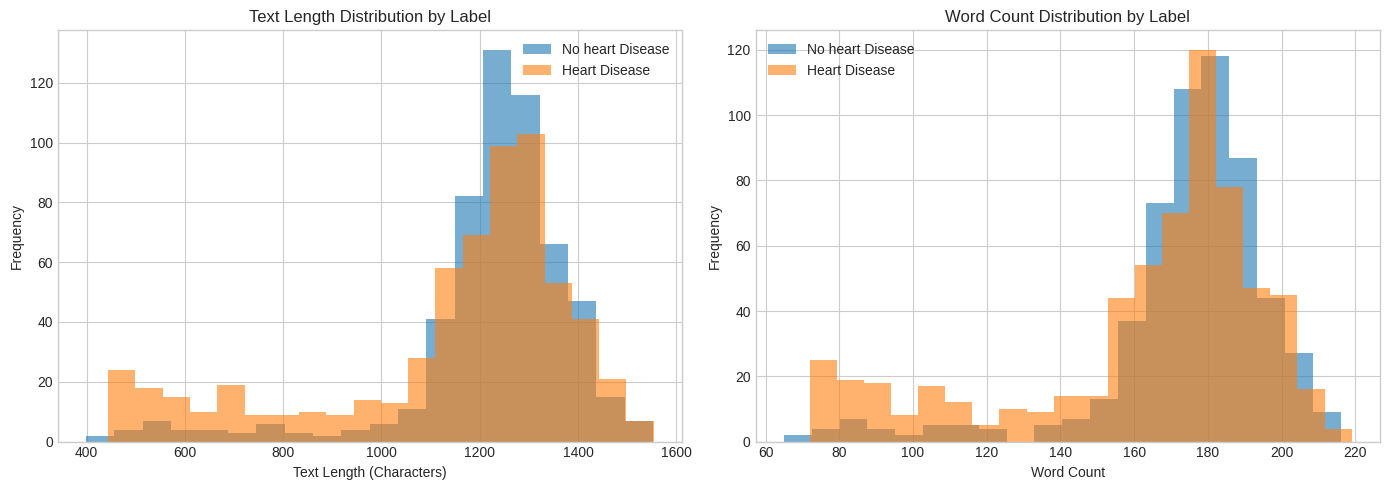

In [6]:
# Text length analysis
df['text_length'] = df['patient_data'].apply(len)
df['word_count'] = df['patient_data'].apply(lambda x: len(x.split()))

print("=" * 50)
print("TEXT LENGTH STATISTICS")
print("=" * 50)
print(df[['text_length', 'word_count']].describe())

# Plot text length distribution by label
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Character length distribution
for label in df['label'].unique():
    subset = df[df['label'] == label]['text_length']
    axes[0].hist(subset, alpha=0.6, label=label, bins=20)
axes[0].set_xlabel('Text Length (Characters)')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Text Length Distribution by Label')
axes[0].legend()

# Word count distribution
for label in df['label'].unique():
    subset = df[df['label'] == label]['word_count']
    axes[1].hist(subset, alpha=0.6, label=label, bins=20)
axes[1].set_xlabel('Word Count')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Word Count Distribution by Label')
axes[1].legend()

plt.tight_layout()
plt.show()

In [8]:
# Sample text examples
print("=" * 50)
print("SAMPLE TEXT - No Heart Disease")
print("=" * 50)
print(df[df['label'] == 'No heart Disease']['patient_data'].iloc[0][:500] + "...")

print("\n" + "=" * 50)
print("SAMPLE TEXT - Heart Disease")
print("=" * 50)
print(df[df['label'] == 'Heart Disease']['patient_data'].iloc[0][:500] + "...")

SAMPLE TEXT - No Heart Disease
The patient is a 40-year-old male who presented for cardiovascular assessment. On examination, his resting blood pressure was recorded at 140 mm Hg, indicating hypertension, a known risk factor for cardiovascular disease. The patient's serum cholesterol level was significantly elevated at 289 mg/dL, further contributing to his cardiovascular risk profile. Despite these findings, his fasting blood sugar was within normal limits, suggesting no immediate concerns for diabetes mellitus. The patient ...

SAMPLE TEXT - Heart Disease
The patient is a 49-year-old female who presented for a routine cardiovascular assessment. Despite being asymptomatic with respect to chest pain, her resting blood pressure is significantly elevated at 160 mm Hg, indicating a hypertensive state that poses a considerable risk for cardiovascular disease. Her serum cholesterol level is measured at 180 mg/dL, which is within normal limits, and her fasting blood sugar is also normal, sug

## 4. Text Preprocessing

In [9]:
# Initialize stopwords
stop_words = set(stopwords.words('english'))

def preprocess_text(text):
    """
    Preprocess text: lowercase, tokenization, stopword removal
    """
    # Convert to lowercase
    text = text.lower()

    # Tokenization
    tokens = word_tokenize(text)

    # Remove stopwords and non-alphabetic tokens
    tokens = [token for token in tokens if token.isalpha() and token not in stop_words]

    # Join tokens back to string
    return ' '.join(tokens)

# Apply preprocessing
print("Preprocessing text...")
df['processed_text'] = df['patient_data'].apply(preprocess_text)
print("Preprocessing complete!")

# Show example
print("\n" + "=" * 50)
print("PREPROCESSING EXAMPLE")
print("=" * 50)
print(f"Original (first 300 chars):\n{df['patient_data'].iloc[0][:300]}...")
print(f"\nProcessed (first 300 chars):\n{df['processed_text'].iloc[0][:300]}...")

Preprocessing text...
Preprocessing complete!

PREPROCESSING EXAMPLE
Original (first 300 chars):
The patient is a 40-year-old male who presented for cardiovascular assessment. On examination, his resting blood pressure was recorded at 140 mm Hg, indicating hypertension, a known risk factor for cardiovascular disease. The patient's serum cholesterol level was significantly elevated at 289 mg/dL,...

Processed (first 300 chars):
patient male presented cardiovascular assessment examination resting blood pressure recorded mm hg indicating hypertension known risk factor cardiovascular disease patient serum cholesterol level significantly elevated contributing cardiovascular risk profile despite findings fasting blood sugar wit...


In [10]:
# Word count after preprocessing
df['processed_word_count'] = df['processed_text'].apply(lambda x: len(x.split()))

print("Word Count Comparison (Before vs After Preprocessing):")
print(f"Before - Mean: {df['word_count'].mean():.2f}, Std: {df['word_count'].std():.2f}")
print(f"After  - Mean: {df['processed_word_count'].mean():.2f}, Std: {df['processed_word_count'].std():.2f}")
print(f"\nReduction: {((df['word_count'].mean() - df['processed_word_count'].mean()) / df['word_count'].mean() * 100):.1f}%")

Word Count Comparison (Before vs After Preprocessing):
Before - Mean: 168.02, Std: 31.26
After  - Mean: 104.58, Std: 20.81

Reduction: 37.8%


## 5. Prepare Data for Modeling

In [11]:
# Encode labels
le = LabelEncoder()
df['label_encoded'] = le.fit_transform(df['label'])

print("Label Encoding:")
for i, label in enumerate(le.classes_):
    print(f"  {label} -> {i}")

# Prepare features and target
X = df['processed_text']
y = df['label_encoded']

# Train-test split (80-20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\nTrain set size: {len(X_train)}")
print(f"Test set size: {len(X_test)}")
print(f"\nTrain label distribution:")
print(pd.Series(y_train).value_counts())
print(f"\nTest label distribution:")
print(pd.Series(y_test).value_counts())

Label Encoding:
  Heart Disease -> 0
  No heart Disease -> 1

Train set size: 952
Test set size: 238

Train label distribution:
label_encoded
0    503
1    449
Name: count, dtype: int64

Test label distribution:
label_encoded
0    126
1    112
Name: count, dtype: int64


## 6. Feature Extraction

In [12]:
# TF-IDF Vectorizer
tfidf_vectorizer = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2),  # Unigrams and bigrams
    min_df=2,
    max_df=0.95
)

X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
X_test_tfidf = tfidf_vectorizer.transform(X_test)

print("TF-IDF Vectorization:")
print(f"  Vocabulary size: {len(tfidf_vectorizer.vocabulary_)}")
print(f"  Train shape: {X_train_tfidf.shape}")
print(f"  Test shape: {X_test_tfidf.shape}")

TF-IDF Vectorization:
  Vocabulary size: 4382
  Train shape: (952, 4382)
  Test shape: (238, 4382)


In [13]:
# Bag of Words (CountVectorizer)
bow_vectorizer = CountVectorizer(
    max_features=5000,
    ngram_range=(1, 2),  # Unigrams and bigrams
    min_df=2,
    max_df=0.95
)

X_train_bow = bow_vectorizer.fit_transform(X_train)
X_test_bow = bow_vectorizer.transform(X_test)

print("Bag of Words Vectorization:")
print(f"  Vocabulary size: {len(bow_vectorizer.vocabulary_)}")
print(f"  Train shape: {X_train_bow.shape}")
print(f"  Test shape: {X_test_bow.shape}")

Bag of Words Vectorization:
  Vocabulary size: 4382
  Train shape: (952, 4382)
  Test shape: (238, 4382)


## 7. Model Training and Evaluation

In [14]:
def evaluate_model(model, X_train, X_test, y_train, y_test, model_name, feature_name):
    """
    Train and evaluate a model, return metrics and predictions
    """
    # Train
    model.fit(X_train, y_train)

    # Predict
    y_pred = model.predict(X_test)

    # Get probabilities for ROC-AUC
    if hasattr(model, 'predict_proba'):
        y_prob = model.predict_proba(X_test)[:, 1]
    else:
        y_prob = model.decision_function(X_test)

    # Calculate metrics
    metrics = {
        'Model': model_name,
        'Features': feature_name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1-Score': f1_score(y_test, y_pred),
        'ROC-AUC': roc_auc_score(y_test, y_prob)
    }

    return metrics, y_pred, y_prob

def plot_confusion_matrix(y_test, y_pred, model_name, feature_name, ax):
    """
    Plot confusion matrix
    """
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['No Heart Disease', 'Heart Disease'],
                yticklabels=['No Heart Disease', 'Heart Disease'])
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
    ax.set_title(f'{model_name} + {feature_name}')

# Store results
results = []
predictions = {}

### 7.1 SVM with TF-IDF

In [15]:
# SVM with TF-IDF
svm_tfidf = SVC(kernel='linear', probability=True, random_state=42)
metrics, y_pred, y_prob = evaluate_model(
    svm_tfidf, X_train_tfidf, X_test_tfidf, y_train, y_test, 'SVM', 'TF-IDF'
)
results.append(metrics)
predictions['SVM_TF-IDF'] = {'y_pred': y_pred, 'y_prob': y_prob}

print("=" * 60)
print("SVM + TF-IDF RESULTS")
print("=" * 60)
print(f"\nAccuracy:  {metrics['Accuracy']:.4f}")
print(f"Precision: {metrics['Precision']:.4f}")
print(f"Recall:    {metrics['Recall']:.4f}")
print(f"F1-Score:  {metrics['F1-Score']:.4f}")
print(f"ROC-AUC:   {metrics['ROC-AUC']:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['No Heart Disease', 'Heart Disease']))

SVM + TF-IDF RESULTS

Accuracy:  0.8403
Precision: 0.8426
Recall:    0.8125
F1-Score:  0.8273
ROC-AUC:   0.9087

Classification Report:
                  precision    recall  f1-score   support

No Heart Disease       0.84      0.87      0.85       126
   Heart Disease       0.84      0.81      0.83       112

        accuracy                           0.84       238
       macro avg       0.84      0.84      0.84       238
    weighted avg       0.84      0.84      0.84       238



### 7.2 SVM with Bag of Words

In [16]:
# SVM with BoW
svm_bow = SVC(kernel='linear', probability=True, random_state=42)
metrics, y_pred, y_prob = evaluate_model(
    svm_bow, X_train_bow, X_test_bow, y_train, y_test, 'SVM', 'BoW'
)
results.append(metrics)
predictions['SVM_BoW'] = {'y_pred': y_pred, 'y_prob': y_prob}

print("=" * 60)
print("SVM + BAG OF WORDS RESULTS")
print("=" * 60)
print(f"\nAccuracy:  {metrics['Accuracy']:.4f}")
print(f"Precision: {metrics['Precision']:.4f}")
print(f"Recall:    {metrics['Recall']:.4f}")
print(f"F1-Score:  {metrics['F1-Score']:.4f}")
print(f"ROC-AUC:   {metrics['ROC-AUC']:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['No Heart Disease', 'Heart Disease']))

SVM + BAG OF WORDS RESULTS

Accuracy:  0.8151
Precision: 0.8333
Recall:    0.7589
F1-Score:  0.7944
ROC-AUC:   0.8827

Classification Report:
                  precision    recall  f1-score   support

No Heart Disease       0.80      0.87      0.83       126
   Heart Disease       0.83      0.76      0.79       112

        accuracy                           0.82       238
       macro avg       0.82      0.81      0.81       238
    weighted avg       0.82      0.82      0.81       238



### 7.3 MLP with TF-IDF

In [17]:
# MLP with TF-IDF
mlp_tfidf = MLPClassifier(
    hidden_layer_sizes=(128, 64),
    activation='relu',
    max_iter=500,
    random_state=42,
    early_stopping=True,
    validation_fraction=0.1
)
metrics, y_pred, y_prob = evaluate_model(
    mlp_tfidf, X_train_tfidf, X_test_tfidf, y_train, y_test, 'MLP', 'TF-IDF'
)
results.append(metrics)
predictions['MLP_TF-IDF'] = {'y_pred': y_pred, 'y_prob': y_prob}

print("=" * 60)
print("MLP + TF-IDF RESULTS")
print("=" * 60)
print(f"\nAccuracy:  {metrics['Accuracy']:.4f}")
print(f"Precision: {metrics['Precision']:.4f}")
print(f"Recall:    {metrics['Recall']:.4f}")
print(f"F1-Score:  {metrics['F1-Score']:.4f}")
print(f"ROC-AUC:   {metrics['ROC-AUC']:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['No Heart Disease', 'Heart Disease']))

MLP + TF-IDF RESULTS

Accuracy:  0.8151
Precision: 0.8400
Recall:    0.7500
F1-Score:  0.7925
ROC-AUC:   0.8873

Classification Report:
                  precision    recall  f1-score   support

No Heart Disease       0.80      0.87      0.83       126
   Heart Disease       0.84      0.75      0.79       112

        accuracy                           0.82       238
       macro avg       0.82      0.81      0.81       238
    weighted avg       0.82      0.82      0.81       238



### 7.4 MLP with Bag of Words

In [18]:
# MLP with BoW
mlp_bow = MLPClassifier(
    hidden_layer_sizes=(128, 64),
    activation='relu',
    max_iter=500,
    random_state=42,
    early_stopping=True,
    validation_fraction=0.1
)
metrics, y_pred, y_prob = evaluate_model(
    mlp_bow, X_train_bow, X_test_bow, y_train, y_test, 'MLP', 'BoW'
)
results.append(metrics)
predictions['MLP_BoW'] = {'y_pred': y_pred, 'y_prob': y_prob}

print("=" * 60)
print("MLP + BAG OF WORDS RESULTS")
print("=" * 60)
print(f"\nAccuracy:  {metrics['Accuracy']:.4f}")
print(f"Precision: {metrics['Precision']:.4f}")
print(f"Recall:    {metrics['Recall']:.4f}")
print(f"F1-Score:  {metrics['F1-Score']:.4f}")
print(f"ROC-AUC:   {metrics['ROC-AUC']:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['No Heart Disease', 'Heart Disease']))

MLP + BAG OF WORDS RESULTS

Accuracy:  0.8361
Precision: 0.8411
Recall:    0.8036
F1-Score:  0.8219
ROC-AUC:   0.8962

Classification Report:
                  precision    recall  f1-score   support

No Heart Disease       0.83      0.87      0.85       126
   Heart Disease       0.84      0.80      0.82       112

        accuracy                           0.84       238
       macro avg       0.84      0.83      0.84       238
    weighted avg       0.84      0.84      0.84       238



## 8. Results Comparison

In [19]:
# Create results DataFrame
results_df = pd.DataFrame(results)
results_df = results_df.round(4)

print("=" * 80)
print("MODEL COMPARISON SUMMARY")
print("=" * 80)
print(results_df.to_string(index=False))

# Find best model
best_idx = results_df['F1-Score'].idxmax()
print(f"\n🏆 Best Model (by F1-Score): {results_df.loc[best_idx, 'Model']} + {results_df.loc[best_idx, 'Features']}")
print(f"   F1-Score: {results_df.loc[best_idx, 'F1-Score']:.4f}")

MODEL COMPARISON SUMMARY
Model Features  Accuracy  Precision  Recall  F1-Score  ROC-AUC
  SVM   TF-IDF    0.8403     0.8426  0.8125    0.8273   0.9087
  SVM      BoW    0.8151     0.8333  0.7589    0.7944   0.8827
  MLP   TF-IDF    0.8151     0.8400  0.7500    0.7925   0.8873
  MLP      BoW    0.8361     0.8411  0.8036    0.8219   0.8962

🏆 Best Model (by F1-Score): SVM + TF-IDF
   F1-Score: 0.8273


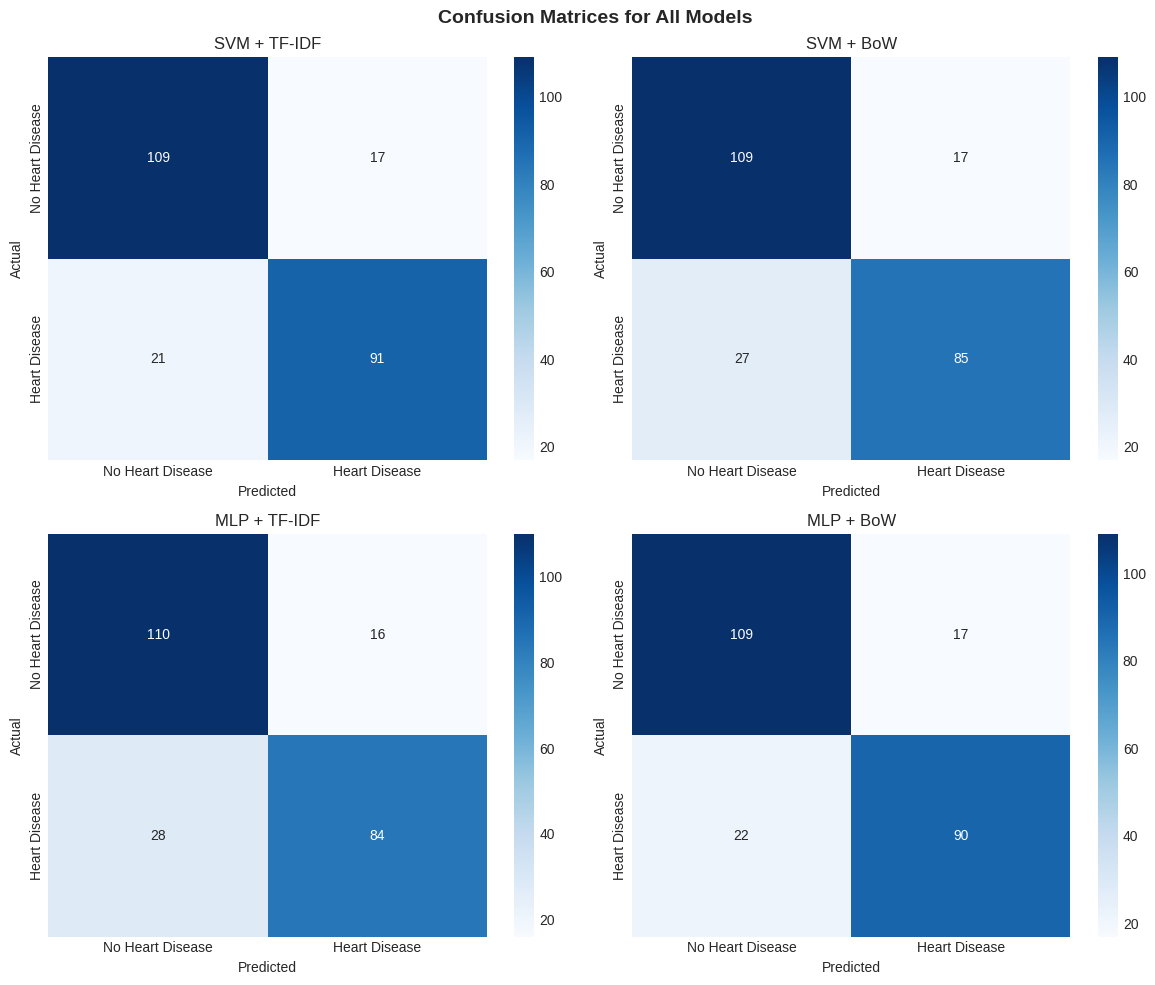

In [20]:
# Confusion Matrix Plots for all models
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

models_names = ['SVM_TF-IDF', 'SVM_BoW', 'MLP_TF-IDF', 'MLP_BoW']
titles = [
    ('SVM', 'TF-IDF'), ('SVM', 'BoW'),
    ('MLP', 'TF-IDF'), ('MLP', 'BoW')
]

for ax, model_key, (model_name, feature_name) in zip(axes.flatten(), models_names, titles):
    plot_confusion_matrix(y_test, predictions[model_key]['y_pred'], model_name, feature_name, ax)

plt.suptitle('Confusion Matrices for All Models', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

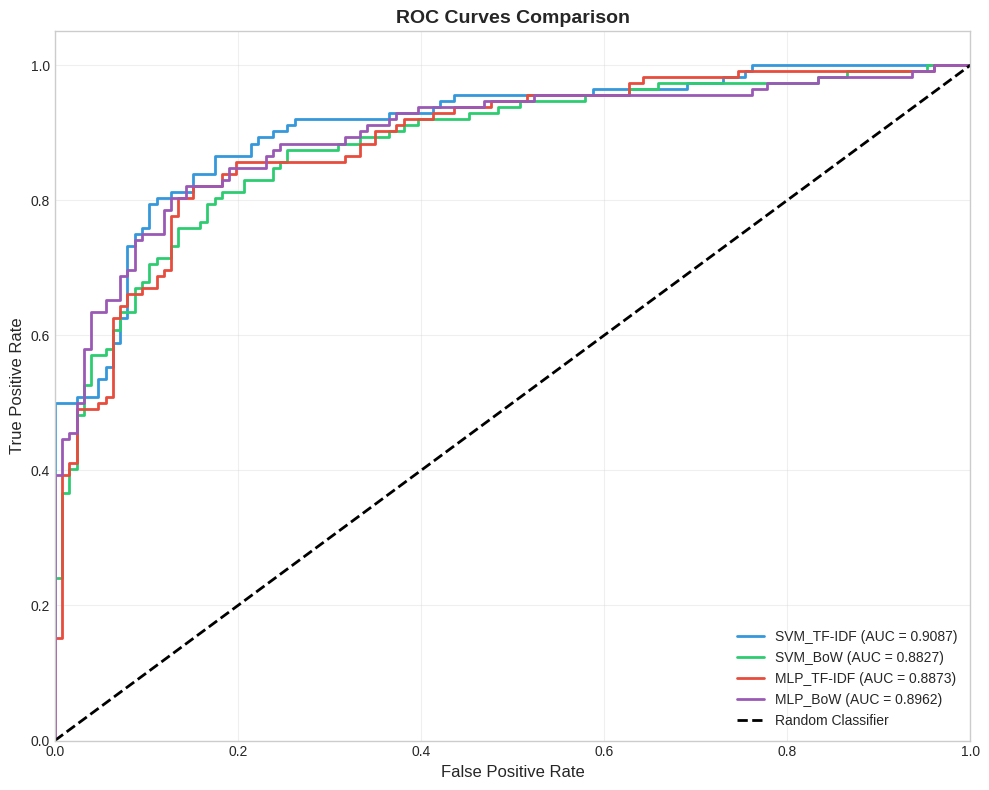

In [21]:
# ROC Curves
fig, ax = plt.subplots(figsize=(10, 8))

colors = ['#3498db', '#2ecc71', '#e74c3c', '#9b59b6']
for (model_key, pred_data), color in zip(predictions.items(), colors):
    fpr, tpr, _ = roc_curve(y_test, pred_data['y_prob'])
    auc = roc_auc_score(y_test, pred_data['y_prob'])
    ax.plot(fpr, tpr, color=color, lw=2, label=f'{model_key} (AUC = {auc:.4f})')

ax.plot([0, 1], [0, 1], 'k--', lw=2, label='Random Classifier')
ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curves Comparison', fontsize=14, fontweight='bold')
ax.legend(loc='lower right', fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

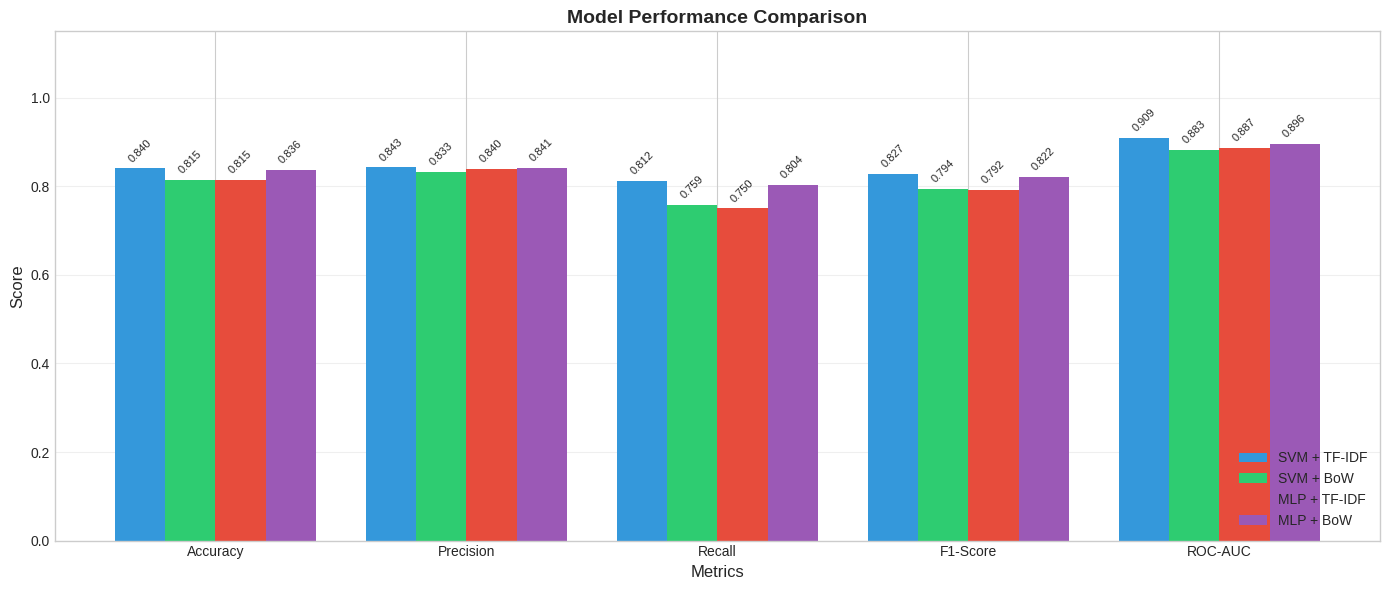

In [22]:
# Metrics comparison bar chart
metrics_to_plot = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
x = np.arange(len(metrics_to_plot))
width = 0.2

fig, ax = plt.subplots(figsize=(14, 6))

model_labels = ['SVM + TF-IDF', 'SVM + BoW', 'MLP + TF-IDF', 'MLP + BoW']
colors = ['#3498db', '#2ecc71', '#e74c3c', '#9b59b6']

for i, (idx, row) in enumerate(results_df.iterrows()):
    values = [row[m] for m in metrics_to_plot]
    bars = ax.bar(x + i*width, values, width, label=model_labels[i], color=colors[i])
    # Add value labels on bars
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{val:.3f}', ha='center', va='bottom', fontsize=8, rotation=45)

ax.set_xlabel('Metrics', fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Model Performance Comparison', fontsize=14, fontweight='bold')
ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(metrics_to_plot)
ax.legend(loc='lower right')
ax.set_ylim(0, 1.15)
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

In [23]:
# Save results to CSV
results_df.to_csv('model_comparison_results.csv', index=False)
print("Results saved to 'model_comparison_results.csv'")

# Final Summary
print("\n" + "=" * 80)
print("FINAL SUMMARY")
print("=" * 80)
print(f"\nDataset: {len(df)} samples")
print(f"Train/Test Split: 80/20")
print(f"Feature Extraction Methods: TF-IDF, Bag of Words")
print(f"Models Trained: SVM (Linear), MLP (128-64)")
print(f"\nBest Performing Model: {results_df.loc[best_idx, 'Model']} + {results_df.loc[best_idx, 'Features']}")
print(f"  - Accuracy:  {results_df.loc[best_idx, 'Accuracy']:.4f}")
print(f"  - Precision: {results_df.loc[best_idx, 'Precision']:.4f}")
print(f"  - Recall:    {results_df.loc[best_idx, 'Recall']:.4f}")
print(f"  - F1-Score:  {results_df.loc[best_idx, 'F1-Score']:.4f}")
print(f"  - ROC-AUC:   {results_df.loc[best_idx, 'ROC-AUC']:.4f}")

Results saved to 'model_comparison_results.csv'

FINAL SUMMARY

Dataset: 1190 samples
Train/Test Split: 80/20
Feature Extraction Methods: TF-IDF, Bag of Words
Models Trained: SVM (Linear), MLP (128-64)

Best Performing Model: SVM + TF-IDF
  - Accuracy:  0.8403
  - Precision: 0.8426
  - Recall:    0.8125
  - F1-Score:  0.8273
  - ROC-AUC:   0.9087
